# 第 12 章 · 手写数字去噪重建代码实验

本页把去噪任务单独拿出来看：给模型一张带噪数字，让它输出更干净的数字。读者重点比较 noisy 和 denoised 的 MSE 与图像差异。

[章节网页](../ch12.html)

## 运行内容

- 加载手写数字数据
- 训练去噪模型
- 比较噪声输入和去噪输出

## 0. 去噪重建

这个实验不是完整扩散模型，而是用真实数据做去噪子任务。它帮助读者理解反向扩散每一步要学习的修复方向。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# Digits 去噪自编码器：把带噪手写数字恢复成干净图像。
digits = load_digits()
X_clean = digits.data / 16.0
rng = np.random.default_rng(19)
noise_sigma = 0.42
X_noisy = np.clip(X_clean + rng.normal(0, noise_sigma, X_clean.shape), 0, 1)

X_train_noisy, X_test_noisy, X_train_clean, X_test_clean = train_test_split(
    X_noisy,
    X_clean,
    test_size=0.2,
    random_state=19,
)
denoiser = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(96,), max_iter=160, random_state=19),
)
denoiser.fit(X_train_noisy, X_train_clean)
X_denoised = np.clip(denoiser.predict(X_test_noisy), 0, 1)

denoise_summary = pd.DataFrame(
    [
        {"图像": "noisy", "MSE": mean_squared_error(X_test_clean, X_test_noisy)},
        {"图像": "denoised", "MSE": mean_squared_error(X_test_clean, X_denoised)},
    ]
).round(4)
display(denoise_summary)

,图像,MSE
0,noisy,0.0920
1,denoised,0.0383


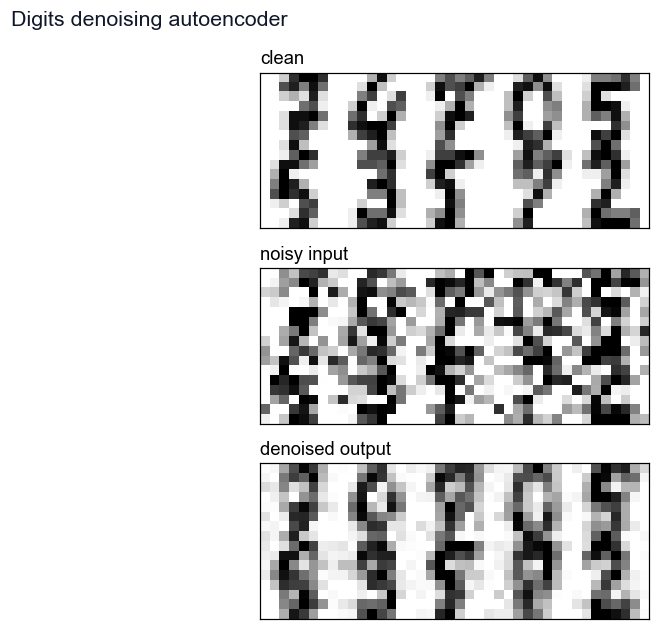

In [3]:
# 绘制干净图像、加噪输入和模型去噪输出。
preview_n = 10
clean_tile = np.block([[X_test_clean[i * 5 + j].reshape(8, 8) for j in range(5)] for i in range(2)])
noisy_tile = np.block([[X_test_noisy[i * 5 + j].reshape(8, 8) for j in range(5)] for i in range(2)])
denoised_tile = np.block([[X_denoised[i * 5 + j].reshape(8, 8) for j in range(5)] for i in range(2)])

fig, axes = plt.subplots(3, 1, figsize=(9.6, 5.8))
for ax, image, title in zip(axes, [clean_tile, noisy_tile, denoised_tile], ["clean", "noisy input", "denoised output"]):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Digits denoising autoencoder", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()